# Bayesian Inference with a Mixture Prior

Author: Fred J. Hickernell

This example explores inference for a normal mean: confidence intervals,
mixture priors, likelihoods, exact posterior calculations, and MCMC. Exact answers
let us separate **inference about the parameter** from **error in the sampler**.

Use the local `qmcpy` Jupyter kernel, or a private Google Colab copy:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH565Fall2026/blob/main/notebooks/applications/BayesianMCMC.ipynb)

Run all cells in order. The setup installs the course's recorded dependency commits
and TeX support in Colab. Keep the complete course checkout, including
`notebooks/mcmc_examples.py`. Save a copy in Drive to retain your experiments.

In [1]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib, QMCPy, and TeX; this may take several minutes …")
    course_checkout = Path("/content/MATH565Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH565Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "-c", "submodule.qmcpy.url=https://github.com/QMCSoftware/qmcpy.git",
            "submodule", "update", "--init", "classlib", "qmcpy",
        ],
        check=True,
    )
    if shutil.which("latex") is None:
        subprocess.run(
            [
                "apt-get", "-qq", "install", "-y",
                "cm-super", "dvipng", "texlive-latex-extra",
                "texlive-latex-recommended",
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            str(course_checkout / "classlib"),
            str(course_checkout / "qmcpy"),
            "arviz>=0.17,<2",
        ],
        check=True,
    )
    print("Colab setup complete.")
    print("For faster repeated work, use the local `qmcpy` environment.")


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import norm
from IPython.display import display, Markdown
import classlib as cl

%matplotlib inline
cl.nbviz.init(use_tex=True)
colors = cl.nbviz.TOL_BRIGHT
rng = np.random.default_rng()

# Locate the same course helper from local Jupyter or the Colab checkout.
search_roots = ([course_checkout] if colab else []) + [Path.cwd(), *Path.cwd().parents]
notebook_dir = next((p / 'notebooks' for p in search_roots
                     if (p / 'notebooks' / 'mcmc_examples.py').is_file()), None)
if notebook_dir is None:
    raise FileNotFoundError('Open this notebook inside the complete MATH565Fall2026 checkout')
sys.path.insert(0, str(notebook_dir))
from mcmc_examples import (log_banana, banana_reference, banana_mean,
                           random_walk_nd, parallel_tempering, mmd_squared, gaussian_kernel)


## Data and frequentist inference

Our goal is to learn an unknown population mean from a small sample, then use
MCMC to explore our uncertainty about that mean. We begin with a familiar
frequentist estimate and confidence interval. Next, we suppose that information
available before observing these data suggests two plausible locations for the
mean. We express that information as a prior distribution and update it using
the observations to obtain a posterior distribution.

This example has an exact posterior, so we can check whether MCMC reproduces it.
In particular, we will see how a chain can miss one of two plausible regions,
and whether parallel tempering helps it explore both.

### A normal mean with known observation variance

Let $Y_0,\ldots,Y_{n-1}\stackrel{\mathrm{IID}}\sim\operatorname{Norm}(\mu,\sigma^2)$,
with $\sigma$ known. The sample mean is $\widehat\mu=\overline{Y}$ and the usual 95% confidence
interval is
\begin{align*}
\left[\widehat\mu-z_{0.975}\frac\sigma{\sqrt n},\;
      \widehat\mu+z_{0.975}\frac\sigma{\sqrt n}\right].
\end{align*}
Across repeated data sets at a fixed $\mu$, this procedure covers $\mu$ with probability
0.95. It does not assign a posterior probability to the fixed unknown parameter.

### Simulated observations

We use ten simulated observations, stored explicitly
below so the data stay fixed when the notebook is rerun. The MCMC runs are freshly randomized. Change `data_shift` to explore
how different observations move the likelihood and posterior; this deliberately
changes the data, not merely the computation.

Sample mean: **0.356**; 95% confidence interval: **[-2.124, 2.835]**

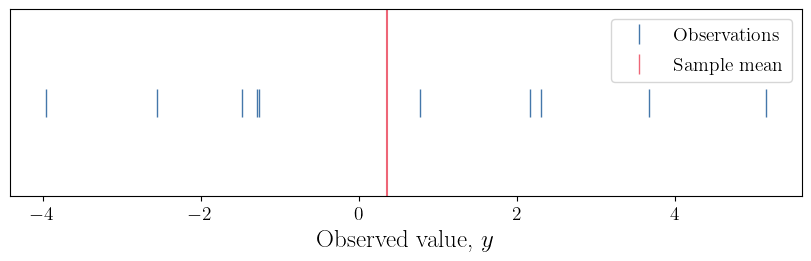

In [3]:
simulated_data = np.array([-3.95648540, -1.47114661, 5.15170105, 0.77589768, 3.68092360,
                   2.30841517, -2.54585459, 2.16780888, -1.26638180, -1.28955646])
data_shift = 0.0
sigma = 4.0
y = simulated_data + data_shift
n_data = len(y)
ybar = y.mean()
se = sigma / np.sqrt(n_data)
ci = ybar + norm.ppf([0.025, 0.975])*se
display(Markdown(f'Sample mean: **{ybar:.3f}**; 95% confidence interval: '
                 f'**[{ci[0]:.3f}, {ci[1]:.3f}]**'))
fig, ax = plt.subplots(figsize=(8, 2.5), constrained_layout=True)
observation_markers, = ax.plot(y, np.zeros_like(y), '|', markersize=20,
                               label='Observations')
ax.axvline(ybar, color=colors['red'])
legend_markersize = 14
observation_legend = Line2D([], [], color=observation_markers.get_color(), marker='|',
                            linestyle='None', markersize=legend_markersize,
                            label='Observations')
sample_mean_legend = Line2D([], [], color=colors['red'], marker='|',
                            linestyle='None', markersize=legend_markersize,
                            label='Sample mean')
ax.set(xlabel=r'Observed value, $y$', yticks=[])
ax.legend(handles=[observation_legend, sample_mean_legend], frameon=True,
          labelspacing=0.65)
plt.show()


## Prior, likelihood, and posterior

Bayesian inference is especially useful when the data provide limited information
relative to the complexity of the model—for example, with a small sample, many
unknown parameters, or noisy observations. A scientifically justified prior can
incorporate existing knowledge and constrain parameter values that the data alone
cannot distinguish well. The posterior then describes uncertainty using both
sources of information.

This is a motivation, not a requirement: Bayesian methods also apply with abundant
data. When the data are weak, conclusions can depend strongly on the prior, so we
should examine how they change under other plausible priors. Our example has only
one unknown mean, but its ten noisy observations make this influence easy to see.

The confidence interval above summarizes what the observations tell us about
$\mu$ through a procedure with repeated-sampling coverage. Now suppose we also
have information about the source of the data before seeing these observations:
we believe the population mean is likely to be near either $-a$ or $a$, with
neither location initially favored. How should this prior information and the
evidence in the sample combine?

We put a **prior distribution on the unknown mean $\mu$**. Conditional on that
one common mean, all observations still follow the normal sampling model above;
we are not assigning each observation to a different mixture component. Bayes'
rule combines the prior with the likelihood of the observed data to give the
**posterior distribution of $\mu$ given the data**. We will use this posterior
to describe which means are plausible and as the target distribution for MCMC.

### A two-component prior on the unknown mean

The two prior components represent the two plausible locations of the mean.
The parameter $\tau$ describes uncertainty around each location, and the equal
weights express our initial lack of preference between them.

Let $\mu$ have prior $\tfrac12\operatorname{Norm}(-a,\tau^2)
+\tfrac12\operatorname{Norm}(a,\tau^2)$. Its density is proportional to
\begin{align*}
\varrho_{\mathrm{prior}}(\mu)&\propto
\exp\left[-\frac{(\mu+a)^2}{2\tau^2}\right]
+\exp\left[-\frac{(\mu-a)^2}{2\tau^2}\right].
\end{align*}
The negative signs are essential. The likelihood as a function of $\mu$ is
\begin{align*}
L(\mu;y)&\propto\exp\left[-\frac{(\mu-\overline{y})^2}{2\sigma^2/n}\right],&
\varrho_{\mathrm{post}}(\mu\mid y)&\propto L(\mu;y)\varrho_{\mathrm{prior}}(\mu).
\end{align*}
A likelihood is not generally a probability density over its parameter. We normalize
this normal-shaped likelihood over $\mu$ **only for the comparison plot**.

### An exact mixture posterior

Write $c_-=-a$, $c_+=a$. Completing the square gives
\begin{align*}
s^2&=(\tau^{-2}+n\sigma^{-2})^{-1},&
m_j&=s^2(c_j/\tau^2+n\overline{y}/\sigma^2),\\
\widetilde w_j&=\tfrac12\exp\left[-\frac{(\overline{y}-c_j)^2}{2(\tau^2+\sigma^2/n)}\right],&
w_j&=\frac{\widetilde w_j}{\widetilde w_-+\widetilde w_+},\\
\mu\mid y&\sim w_-\operatorname{Norm}(m_-,s^2)+w_+\operatorname{Norm}(m_+,s^2).
\end{align*}
The data change both component locations and weights. The posterior is available
analytically here; MCMC is a checked demonstration, not a computational necessity.

Posterior weights: **[0.301 0.699]**; component means: **[-1.875  1.912]**; posterior mean: **0.772**

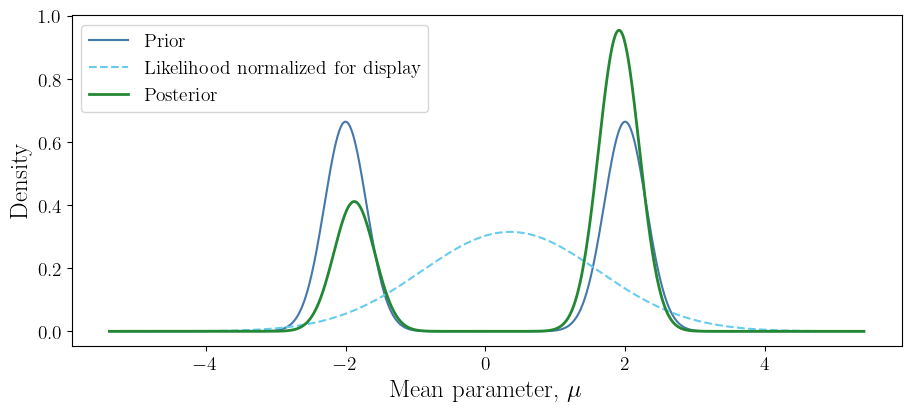

95% equal-tail credible interval: **[-2.279, 2.438]**. Given these data and this prior, it contains 95% posterior probability. It can include the low-density valley; it is not necessarily a highest-density set.

In [4]:
from scipy.special import logsumexp
from scipy.optimize import brentq
prior_a, prior_tau = 2.0, 0.3
prior_means = np.array([-prior_a, prior_a])
post_var = 1/(1/prior_tau**2 + n_data/sigma**2)
post_sd = np.sqrt(post_var)
post_means = post_var*(prior_means/prior_tau**2 + n_data*ybar/sigma**2)
log_weights = np.log(0.5) - 0.5*(ybar-prior_means)**2/(prior_tau**2+sigma**2/n_data)
post_weights = np.exp(log_weights-logsumexp(log_weights))

def log_prior(mu):
    mu = np.asarray(mu)
    return np.logaddexp(norm.logpdf(mu,-prior_a,prior_tau),
                       norm.logpdf(mu,prior_a,prior_tau))-np.log(2)
def log_likelihood(mu):
    return -0.5*n_data*((np.asarray(mu)-ybar)/sigma)**2

def log_posterior(mu):
    return log_prior(mu)+log_likelihood(mu)

def posterior_pdf(mu):
    return sum(w*norm.pdf(mu,m,post_sd) for w,m in zip(post_weights,post_means))
def posterior_cdf(mu):
    return sum(w*norm.cdf(mu,m,post_sd) for w,m in zip(post_weights,post_means))

post_mean = post_weights @ post_means
left_cut = post_means.mean()
left_probability = posterior_cdf(left_cut)
lo, hi = post_means.min()-12*post_sd, post_means.max()+12*post_sd
credible = np.array([brentq(lambda x:posterior_cdf(x)-p,lo,hi) for p in [.025,.975]])
display(Markdown(f'Posterior weights: **{post_weights.round(3)}**; component means: '
                 f'**{post_means.round(3)}**; posterior mean: **{post_mean:.3f}**'))
fig, ax = plt.subplots(figsize=(9,4), constrained_layout=True)
grid = np.linspace(min(-5,lo),max(5,hi),1000)
ax.plot(grid,np.exp(log_prior(grid)),label='Prior')
ax.plot(grid,norm.pdf(grid,ybar,se),'--',label='Likelihood normalized for display')
ax.plot(grid,posterior_pdf(grid),lw=2,label='Posterior')
ax.set(xlabel=r'Mean parameter, $\mu$',ylabel='Density')
ax.legend(frameon=True)
plt.show()
display(Markdown(f'95% equal-tail credible interval: **[{credible[0]:.3f}, {credible[1]:.3f}]**. '
    'Given these data and this prior, it contains 95% posterior probability. '
    'It can include the low-density valley; it is not necessarily a highest-density set.'))


### Interpreting the posterior and its credible interval

The posterior is a distribution for the **one unknown mean $\mu$ shared by all
observations**. Its two components represent two plausible regions for that
mean. Their updated weights tell us how much posterior probability each
component receives; they are not proportions of observations from two different
populations. The data have changed the equal prior weights as well as the
component locations and spreads.

The displayed **95% equal-tail credible interval** has endpoints chosen so that
2.5% of the posterior probability lies below the lower endpoint and 2.5% lies
above the upper endpoint. The remaining 95% lies between them. In symbols, if
those endpoints are $L$ and $U$, then
\begin{align*}
\Pr(\mu<L\mid y)&=0.025, &
\Pr(L\leq\mu\leq U\mid y)&=0.95, &
\Pr(\mu>U\mid y)&=0.025.
\end{align*}
These probabilities describe uncertainty about the mean given this prior and
these observations. They do not say that 95% of the observations fall in this
interval.

**Why does the interval include the valley?** Look at the posterior curve:
most of its area is concentrated around two separated peaks. To include enough
area from both peaks, a single interval must also span the gap between them.
The density in that gap can be very small. Inclusion in the interval therefore
does not mean that every value inside it is equally plausible, or even that
every value inside is more plausible than every value outside. Probability is
area under the curve; a long stretch of very low density can contribute little
area.

A **95% highest-density set** instead collects the values with the largest
posterior density until their total probability is 95%. Imagine drawing a
horizontal line across the posterior plot and retaining the regions where the
curve is above it, adjusting the line until those regions contain 95% of the
area. With well-separated peaks, this set can be two disjoint intervals that
exclude the valley. Both summaries contain 95% posterior probability, but the
equal-tail interval balances the two excluded tails, whereas the highest-density
set retains the most densely supported values. The calculation above reports
only the equal-tail interval; it does not compute the highest-density set.

### Comparing the frequentist and Bayesian conclusions

Both analyses use the same observations and the same normal sampling model,
but they answer different questions.

**Frequentist conclusion.** We estimate the fixed unknown mean by the sample
mean and report the confidence interval calculated above. If we repeatedly
collected samples at that same fixed $\mu$ and constructed an interval this way,
95% of the resulting intervals would contain $\mu$. For the particular interval
we have observed, the frequentist calculation does not assign a 95% probability
to $\mu$ lying inside it: the parameter and the observed endpoints are fixed.
The 95% guarantee belongs to the sampling procedure.

**Bayesian conclusion.** We combine the observations with our stated prior
belief that the common mean is likely to be near one of two locations. Given
these data and this prior, the posterior assigns 95% probability to $\mu$ lying
in the credible interval. It also tells us how posterior probability is divided
between the two components and shows that values in the valley have little
posterior density. The 95% statement belongs to the posterior distribution
conditional on the observed data and the assumed model, including the prior.

The numerical conclusions differ because the Bayesian analysis uses additional
information encoded in the prior. In this example, ten noisy observations leave
room for that prior to strongly influence the posterior: the frequentist
estimate is the sample mean, while the posterior retains two plausible regions
for $\mu$. A single Bayesian point estimate, such as the posterior mean, can lie
between the peaks and hide this distinction. Compare the full posterior curve
with the confidence interval, rather than just comparing two point estimates
or two pairs of endpoints.

A 95% Bayesian credible interval need not have 95% frequentist coverage when
sampling repeatedly at each fixed $\mu$. Conversely, a 95% confidence interval
need not contain 95% posterior probability under the chosen prior. Neither 95%
statement automatically implies the other.

With the current settings, the prior puts equal weight on a mean near $-2$ and
a mean near $+2$. The small component standard deviation, $\tau=0.3$, expresses
fairly strong confidence about the mean's location **within either region**,
while leaving uncertainty about which region is appropriate. It expresses more
than a belief about the sign: a mean near zero or far from both centers receives
little prior density.

If we increase $\tau$ enough that the prior is nearly flat over the range where
the likelihood is appreciable, the likelihood dominates the posterior. In this
normal model with known $\sigma$, the posterior then approaches
$\operatorname{Norm}(\overline{y},\sigma^2/n)$, and its 95% equal-tail credible
interval approaches the usual 95% frequentist confidence interval. Their
endpoints become nearly the same, but their interpretations remain different.
Merely making a prior somewhat more diffuse does not guarantee this agreement;
it must exert little influence over the range supported by the likelihood.

- **Frequentist:** Across repeated samples, 95% of intervals constructed this way contain the fixed true mean.
- **Bayesian:** Given these data and this prior, the mean has 95% posterior probability of lying in this credible interval.


## Sample the posterior and check the answer

### Random walks from dispersed starts

Run narrow and broad Gaussian random-walk proposals from both humps. With a symmetric
proposal, the log acceptance ratio is simply the change in `log_posterior`. The code
uses the same Metropolis implementation as the banana comparison. This posterior is
sharp enough that narrow proposals can stay in their starting hump for the whole run.

Use four chains per setting. A small within-chain standard error is not reassuring
if different starting states give different answers.

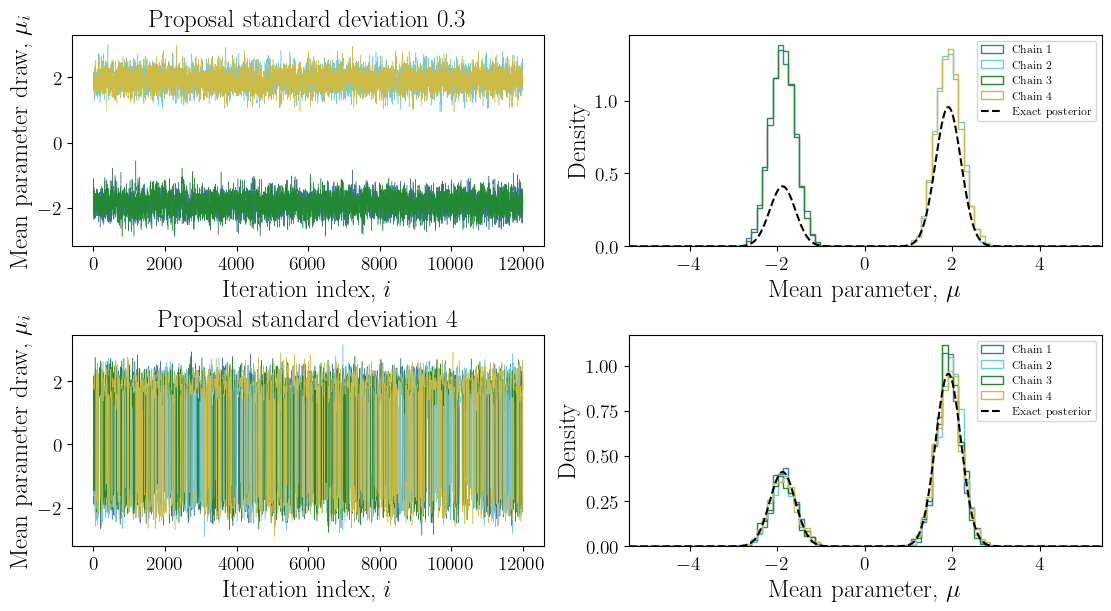

| Proposal sd | Chain | Acceptance | Mean | Left fraction |
|---:|---:|---:|---:|---:|
| 0.3 | 1 | 69.6% | -1.880 | 1.000 |
| 0.3 | 2 | 70.0% | 1.919 | 0.000 |
| 0.3 | 3 | 69.8% | -1.879 | 1.000 |
| 0.3 | 4 | 70.1% | 1.919 | 0.000 |
| 4 | 1 | 13.8% | 0.795 | 0.300 |
| 4 | 2 | 13.7% | 0.882 | 0.277 |
| 4 | 3 | 13.5% | 0.850 | 0.280 |
| 4 | 4 | 13.8% | 0.807 | 0.295 |
| Target | — | — | 0.772 | 0.301 |

In [5]:
n_draws, burn = 12000, 2000
starts = [post_means[0],post_means[1],post_means[0],post_means[1]]
posterior_runs = {}
for sd in [.3,4.]:
    posterior_runs[sd] = [random_walk_nd(lambda x:float(log_posterior(x[0])),
                         [x0],n_draws,sd,rng) for x0 in starts]
fig, axes = plt.subplots(2,2,figsize=(11,6),constrained_layout=True)
for row,sd in enumerate(posterior_runs):
    for j,run in enumerate(posterior_runs[sd]):
        values=run['states'][:,0]
        axes[row,0].plot(np.arange(n_draws),values,lw=.35,label=f'Chain {j+1}')
        axes[row,1].hist(values[burn:],bins=np.linspace(lo,hi,90),density=True,
                          histtype='step',lw=1,label=f'Chain {j+1}')
    axes[row,0].set(xlabel='Iteration index, $i$',ylabel=r'Mean parameter draw, $\mu_i$',title=f'Proposal standard deviation {sd:g}')
    axes[row,1].plot(grid,posterior_pdf(grid),'k--',label='Exact posterior')
    axes[row,1].set(xlabel=r'Mean parameter, $\mu$',ylabel='Density',xlim=(lo,hi))
    axes[row,1].legend(fontsize=8,frameon=True)
plt.show()
rows=['| Proposal sd | Chain | Acceptance | Mean | Left fraction |', '|---:|---:|---:|---:|---:|']
for sd,runs in posterior_runs.items():
    for j,run in enumerate(runs):
        values=run['states'][burn:,0]
        rows.append(f'| {sd:g} | {j+1} | {run["acceptance"]:.1%} | {values.mean():.3f} | '
                    f'{np.mean(values<left_cut):.3f} |')
rows.append(f'| Target | — | — | {post_mean:.3f} | {left_probability:.3f} |')
display(Markdown('\n'.join(rows)))


### Multiple-chain diagnostics with ArviZ

Rank-normalized split $\widehat R$ compares within-chain and between-chain variation;
bulk/tail ESS and Monte Carlo standard errors measure effective sample information
under their diagnostic assumptions. Examine them with the traces and the known target.
Values near $\widehat R=1$ are desirable, but no threshold proves convergence.
For this teaching example, compare the summaries against the exact mean and region mass.
These diagnostics are from ArviZ, already included in the course environment.

In [6]:
import arviz as az
import inspect
for sd,runs in posterior_runs.items():
    draws=np.stack([r['states'][burn:,0] for r in runs])
    posterior = {'mu': draws}
    # ArviZ 1.x accepts a nested group dictionary; 0.x uses group keywords.
    inference_data = (az.from_dict({'posterior': posterior})
                      if 'data' in inspect.signature(az.from_dict).parameters
                      else az.from_dict(posterior=posterior))
    display(Markdown(f'**Proposal standard deviation {sd:g}**'))
    # The parameter summary remains defined even when a chain never changes regions.
    display(az.summary(inference_data,var_names=['mu'],kind='all',round_to=3))


**Proposal standard deviation 0.3**

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,0.02,1.921,-2.235,2.279,6.081,34.565,1.733,0.95,0.143


**Proposal standard deviation 4**

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,0.834,1.74,-2.118,2.32,2755.813,2771.932,1.001,0.039,0.019


### Whole-posterior tempering

Reuse the replica-exchange method developed in
[Metropolis–Hastings](../sampling/MetropolisHastings.ipynb).
Here every replica targets $[L(\mu;y)\varrho_{\mathrm{prior}}(\mu)]^\beta$.
Both likelihood and prior are tempered, so the swap formula uses the full log posterior.
The original posterior is represented only by the cold slot $\beta=1$.

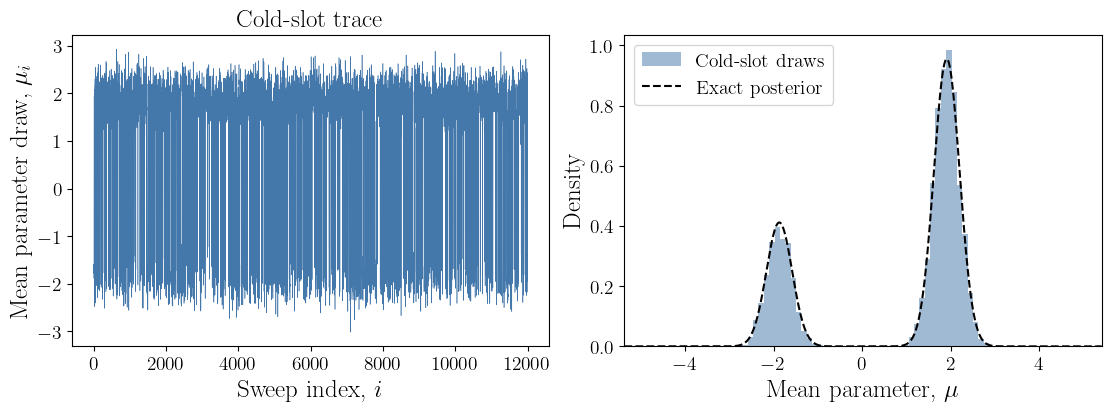

Cold mean: **0.812** (target 0.772); left fraction: **0.290** (target 0.301); log-target evaluations: **60000**. A plain chain with 12000 states costs 12000 evaluations, so these runs do not have equal budgets.

In [7]:
betas=np.array([1.,.5,.2,.08,.025])
pt = parallel_tempering(log_posterior, np.full(len(betas),post_means[0]),
                        betas,n_draws,.3/np.sqrt(betas),rng)
cold=pt['states'][burn:,0]
fig,axes=plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
axes[0].plot(np.arange(n_draws),pt['states'][:,0],lw=.4,color=colors['blue'])
axes[0].set(xlabel='Sweep index, $i$',ylabel=r'Mean parameter draw, $\mu_i$',title='Cold-slot trace')
axes[1].hist(cold,bins=np.linspace(lo,hi,90),density=True,alpha=.5,label='Cold-slot draws')
axes[1].plot(grid,posterior_pdf(grid),'k--',label='Exact posterior')
axes[1].set(xlabel=r'Mean parameter, $\mu$',ylabel='Density',xlim=(lo,hi))
axes[1].legend(frameon=True)
plt.show()
display(Markdown(f'Cold mean: **{cold.mean():.3f}** (target {post_mean:.3f}); '
    f'left fraction: **{np.mean(cold<left_cut):.3f}** (target {left_probability:.3f}); '
    f'log-target evaluations: **{pt["evaluations"]}**. A plain chain with {n_draws} '
    f'states costs {n_draws} evaluations, so these runs do not have equal budgets.'))


## Further study and experiments

### A modern external companion

The official [PyMC API quickstart notebook](https://www.pymc.io/projects/examples/en/latest/introductory/api_quickstart.html)
introduces model specification, sampling, and posterior summaries. Use it as an
optional external companion after this notebook's prior–likelihood–posterior lesson.
It is maintained by PyMC, not by this course. PyMC is not required to run this notebook
and has not been added to the course environment.

NUTS is worth exploring for more complicated continuous posterior models. Do not
assume that switching to a modern local sampler automatically fixes separated modes;
retain dispersed starts, trace review, and diagnostics. An in-course PyMC/NUTS
extension remains a separate decision after its environment requirements are tested.

### Questions

1. Shift the observations. How do the posterior weights, component means, and
   credible interval change? Compare with the confidence interval.
2. Increase the prior spread or decrease its separation. How do the posterior and
   sampler difficulty change together?
3. Increase the number of MCMC iterations while holding the data fixed. Explain why
   this changes Monte Carlo error, not the posterior uncertainty defined by the model.
4. Compare exact posterior quantiles with sampled quantiles. Which chains can support
   the comparison? Why is a mixture of trapped chains with equal lengths misleading?
5. Account for all replicas before comparing tempering's cost with a plain chain.

This example distinguishes uncertainty about the parameter from Monte Carlo
error in approximating the posterior.

In [8]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(f"Total execution time for this notebook is "
      f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec.")


Total execution time for this notebook is 0 min 9.2 sec.
